In [ ]:
import pandas as pd
import numpy as np
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error,mean_absolute_error,r2_score
import matplotlib.pyplot as plt
import seaborn as sns


In [ ]:
df = pd.read_csv('Salary_dataset.csv')
df.head()


,Unnamed: 0,YearsExperience,Salary
0,0,1.2,39344
1,1,1.4,46206
2,2,1.6,37732
3,3,2.1,43526
4,4,2.3,39892


In [ ]:
df.shape

(30, 3)

In [ ]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30 entries, 0 to 29
Data columns (total 3 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Unnamed: 0       30 non-null     int64  
 1   YearsExperience  30 non-null     float64
 2   Salary           30 non-null     int64  
dtypes: float64(1), int64(2)
memory usage: 852.0 bytes


In [ ]:
df.describe()

,Unnamed: 0,YearsExperience,Salary
count,30.000000,30.000000,30.000000
mean,14.500000,5.413333,76004.000000
std,8.803408,2.837888,27414.429785
min,0.000000,1.200000,37732.000000
25%,7.250000,3.300000,56721.750000
50%,14.500000,4.800000,65238.000000
75%,21.750000,7.800000,100545.750000
max,29.000000,10.600000,122392.000000


In [ ]:
df.isnull().sum()


,0
Unnamed: 0,0
YearsExperience,0
Salary,0


In [ ]:
# coinvert years of experence to ther nearest lower integer by removiung decimal values
df['YearsExperience'] = df['YearsExperience'].apply(np.floor)
df.head()

,Unnamed: 0,YearsExperience,Salary
0,0,1.0,39344
1,1,1.0,46206
2,2,1.0,37732
3,3,2.0,43526
4,4,2.0,39892


In [ ]:
x=df.iloc[:,:-1]
x

,Unnamed: 0,YearsExperience
0,0,1.0
1,1,1.0
2,2,1.0
3,3,2.0
4,4,2.0
5,5,3.0
6,6,3.0
7,7,3.0
8,8,3.0
9,9,3.0


In [ ]:
y=df.iloc[:,-1]
y

,Salary
0,39344
1,46206
2,37732
3,43526
4,39892
5,56643
6,60151
7,54446
8,64446
9,57190


In [ ]:
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=42)

In [ ]:
#create the model
model=LinearRegression()


In [ ]:
#train the model
model.fit(x_train,y_train)
print("Model Trained")

Model Trained


In [ ]:
#generate the prediction fopr tainning and testing datasets using the  trained model
y_pred_train=model.predict(x_test)
y_pred_test=model.predict(x_test)
print("predictions generated for both trainning and testing datasets")

predictions generated for both trainning and testing datasets


In [ ]:
#Evaluate thye performance of the model by using the diffrent matrics
print("Mean Squared Error (MSE):",mean_squared_error(y_test,y_pred_test))
print("Root Mean Squared Error (RMSE):",np.sqrt(mean_squared_error(y_test,y_pred_test)))
print("Mean Absolute Error (MAE):",mean_absolute_error(y_test,y_pred_test))
print("R-squared (R2) Score:",r2_score(y_test,y_pred_test))

Mean Squared Error (MSE): 56015684.00939504
Root Mean Squared Error (RMSE): 7484.362632141433
Mean Absolute Error (MAE): 6360.400755587726
R-squared (R2) Score: 0.8903364744511594


In [ ]:
#slope
model.coef_

array([ -171.84073839, 10157.34168853])

In [ ]:
#intercept
model.intercept_

np.float64(25827.686894851126)

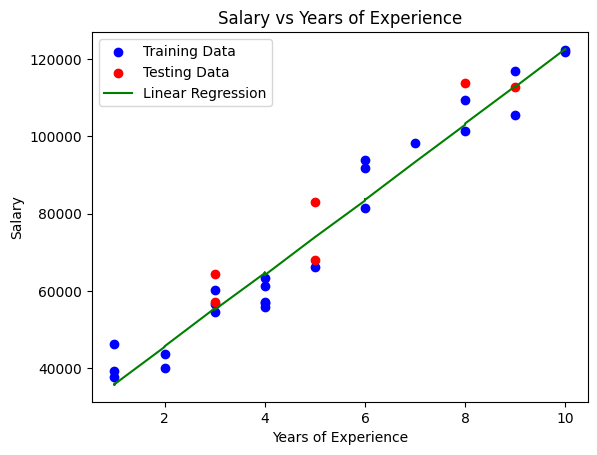

In [ ]:
#polt actual salary datapoints and the fitted linear regression
plt.scatter(x_train['YearsExperience'],y_train,color='blue',label='Training Data')
plt.scatter(x_test['YearsExperience'],y_test,color='red',label='Testing Data')
plot_x_train_sorted = x_train.sort_values(by='YearsExperience')
plot_y_pred_train = model.predict(plot_x_train_sorted)
plt.plot(plot_x_train_sorted['YearsExperience'], plot_y_pred_train, color='green',label='Linear Regression')
plt.xlabel('Years of Experience')
plt.ylabel('Salary')
plt.title('Salary vs Years of Experience')
plt.legend()
plt.show()


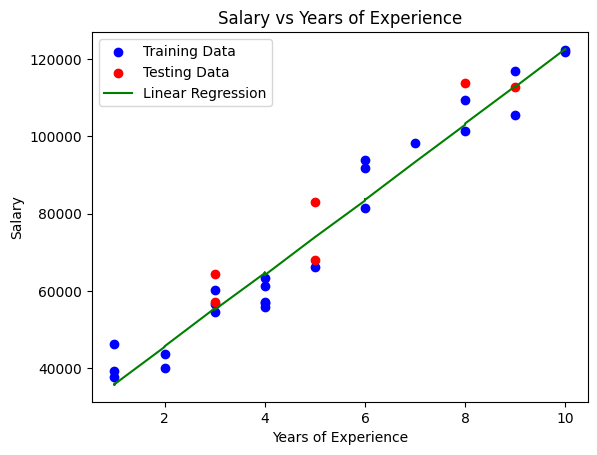

In [ ]:
#polt actual salary datapoints and the fitted linear regression
plt.scatter(x_train['YearsExperience'],y_train,color='blue',label='Training Data')
plt.scatter(x_test['YearsExperience'],y_test,color='red',label='Testing Data')
plot_x_train_sorted = x_train.sort_values(by='YearsExperience')
plot_y_pred_train = model.predict(plot_x_train_sorted)
plt.plot(plot_x_train_sorted['YearsExperience'], plot_y_pred_train, color='green',label='Linear Regression')
plt.xlabel('Years of Experience')
plt.ylabel('Salary')
plt.title('Salary vs Years of Experience')
plt.legend()
plt.show()
